In [1]:
from google.colab import drive
import pandas as pd
import os


drive.mount('/content/drive')
target_path = '/content/drive/MyDrive/Anwendungsprojekt Colab - Unfall /Training_Test_Sets'

# Einlesen der vorbereiteten Trainings- und Testdaten im Parquet-Format
X_train = pd.read_parquet(os.path.join(target_path, 'X_train.parquet'))
X_test = pd.read_parquet(os.path.join(target_path, 'X_test.parquet'))

# Zielvariable (Unfallschwere) für Training und Test extrahieren
y_train = pd.read_parquet(os.path.join(target_path, 'y_train.parquet'))['CRASH_SEVERITY_LEVEL']
y_test = pd.read_parquet(os.path.join(target_path, 'y_test.parquet'))['CRASH_SEVERITY_LEVEL']

print(" Daten im neuen Notebook einsatzbereit!")

Mounted at /content/drive
 Daten im neuen Notebook einsatzbereit!


# XGBoost


## Klassengewichtung (Class Weights)

Wir übergeben dem Modell ein Gewicht für jede Klasse, das umgekehrt proportional zu ihrer Häufigkeit ist.
Die Klassengewichte werden automatisch berechnet und ein erstes XGBoost-Baseline-Modell wird trainiert.

Berechnete Klassengewichte (Invers zur Häufigkeit): {np.int64(0): np.float64(0.297892689841929), np.int64(1): np.float64(1.728995253164557), np.int64(2): np.float64(16.49811273276296), np.int64(3): np.float64(243.73048327137548)}
Starte Modelltraining...
Training abgeschlossen.

--- CLASSIFICATION REPORT ---
                  precision    recall  f1-score   support

Blechschaden (0)       0.92      0.78      0.85     55023
      Leicht (1)       0.32      0.58      0.41      9480
      Schwer (2)       0.05      0.04      0.04       994
     Tödlich (3)       0.02      0.04      0.02        67

        accuracy                           0.74     65564
       macro avg       0.32      0.36      0.33     65564
    weighted avg       0.82      0.74      0.77     65564



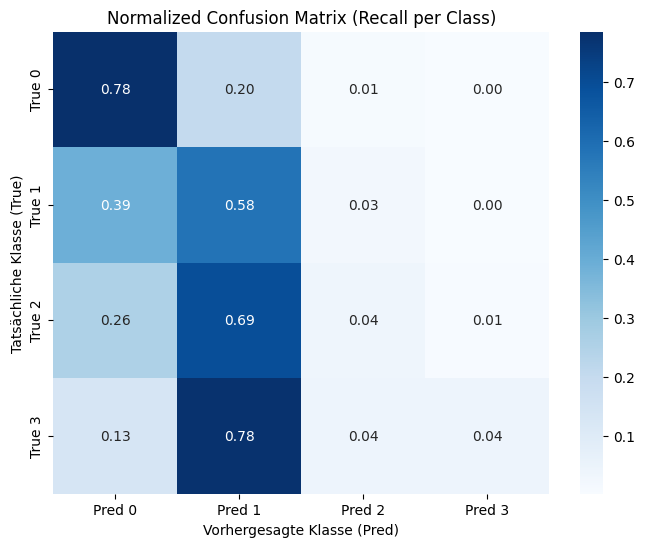

In [2]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Konvertierung von Textspalten in den kategorialen Datentyp für XGBoost
for col in ['TRAFFIC_CONTROL_DEVICE', 'LOCATION']:
    if col in X_train.columns and X_train[col].dtype == 'object':
        X_train[col] = X_train[col].astype('category')
    if col in X_test.columns and X_test[col].dtype == 'object':
        X_test[col] = X_test[col].astype('category')

# Also ensure 'SPEED_CATEGORY' is treated as category if it's not already
if 'SPEED_CATEGORY' in X_train.columns and X_train['SPEED_CATEGORY'].dtype != 'category':
    X_train['SPEED_CATEGORY'] = X_train['SPEED_CATEGORY'].astype('category')
if 'SPEED_CATEGORY' in X_test.columns and X_test['SPEED_CATEGORY'].dtype != 'category':
    X_test['SPEED_CATEGORY'] = X_test['SPEED_CATEGORY'].astype('category')

# Klassengewichte berechnen
y_train_flat = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

classes = np.unique(y_train_flat)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_flat)
class_weights_dict = dict(zip(classes, weights))

print("Berechnete Klassengewichte (Invers zur Häufigkeit):", class_weights_dict)

# Erstelle ein Array von Gewichten für jedes sample im Trainingsset
sample_weights = np.array([class_weights_dict[cls] for cls in y_train_flat])

# Definition des XGBoost-Klassifikators
model = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    tree_method='hist',
    enable_categorical=True # Hinzugefügt, um kategoriale Features zu ermöglichen
)

# Modelltraining unter Berücksichtigung der Instanzgewichtung
print("Starte Modelltraining...")
model.fit(X_train, y_train_flat, sample_weight=sample_weights)
print("Training abgeschlossen.")

# Vorhersagen generieren
y_test_flat = y_test.values.ravel() if hasattr(y_test, 'values') else y_test
y_pred = model.predict(X_test)

# Evaluation
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test_flat, y_pred, target_names=['Blechschaden (0)', 'Leicht (1)', 'Schwer (2)', 'Tödlich (3)']))

# Konfusionsmatrix plotten
cm_normalized = confusion_matrix(y_test_flat, y_pred, normalize='true')
plt.figure(figsize=(8, 6))

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1', 'Pred 2', 'Pred 3'],
            yticklabels=['True 0', 'True 1', 'True 2', 'True 3'])
plt.ylabel('Tatsächliche Klasse (True)')
plt.xlabel('Vorhergesagte Klasse (Pred)')
plt.title('Normalized Confusion Matrix (Recall per Class)')
plt.show()

## Multiklassifikation in binäre Klassifikation
Es wird die 4-Klassen-Multiklassifikation in ein binäres Klassifikation umwandeln (0 = Reiner Blechschaden vs. 1 = Personenschaden).
Wenn wir die Klassen 1 (9.480), 2 (994) und 3 (67) zusammenfassen, kommen wir auf insgesamt 10.541 Fälle von Personenschaden.

Verteilung im Training (0 = Blech, 1 = Person):
CRASH_SEVERITY_LEVEL
0    220091
1     42163
Name: count, dtype: int64
Gewichtungsfaktor (scale_pos_weight): 5.22

Starte binäres Modelltraining...
Training abgeschlossen.

--- BINARY CLASSIFICATION REPORT ---
                     precision    recall  f1-score   support

   Blechschaden (0)       0.92      0.77      0.84     55023
Personenschaden (1)       0.35      0.64      0.45     10541

           accuracy                           0.75     65564
          macro avg       0.63      0.71      0.65     65564
       weighted avg       0.83      0.75      0.78     65564



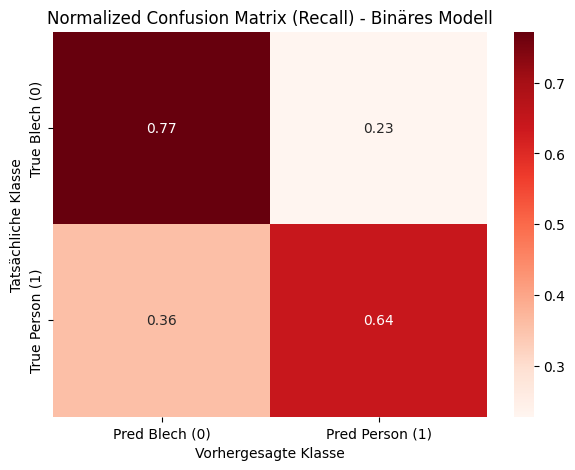

In [3]:
# Daten kopieren und die Zielvariable binarisieren
y_train_bin = y_train.copy()
y_test_bin = y_test.copy()

if isinstance(y_train_bin, pd.DataFrame) or isinstance(y_train_bin, pd.Series):
    y_train_bin = (y_train_bin.iloc[:, 0] if isinstance(y_train_bin, pd.DataFrame) else y_train_bin).apply(lambda x: 1 if x > 0 else 0)
    y_test_bin = (y_test_bin.iloc[:, 0] if isinstance(y_test_bin, pd.DataFrame) else y_test_bin).apply(lambda x: 1 if x > 0 else 0)
else:
    y_train_bin = np.where(y_train_bin > 0, 1, 0)
    y_test_bin = np.where(y_test_bin > 0, 1, 0)

# Berechnen von scale_pos_weight
num_neg = np.sum(y_train_bin == 0)
num_pos = np.sum(y_train_bin == 1)
scale_pos_weight_value = num_neg / num_pos

print("Verteilung im Training (0 = Blech, 1 = Person):")
print(y_train_bin.value_counts() if hasattr(y_train_bin, 'value_counts') else np.bincount(y_train_bin))
print(f"Gewichtungsfaktor (scale_pos_weight): {scale_pos_weight_value:.2f}\n")

# Binäres XGBoost Modell mit maximaler Fehlertoleranz definieren
binary_model = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    tree_method='hist',
    enable_categorical=True
)

print("Starte binäres Modelltraining...")
binary_model.fit(X_train, y_train_bin)
print("Training abgeschlossen.")

# Vorhersagen & Evaluation
y_pred_bin = binary_model.predict(X_test)

print("\n--- BINARY CLASSIFICATION REPORT ---")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Blechschaden (0)', 'Personenschaden (1)']))

# Konfusionsmatrix plotten
cm_bin = confusion_matrix(y_test_bin, y_pred_bin, normalize='true')
plt.figure(figsize=(7, 5))
sns.heatmap(cm_bin, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=['Pred Blech (0)', 'Pred Person (1)'],
            yticklabels=['True Blech (0)', 'True Person (1)'])
plt.ylabel('Tatsächliche Klasse')
plt.xlabel('Vorhergesagte Klasse')
plt.title('Normalized Confusion Matrix (Recall) - Binäres Modell')
plt.show()

## Hyperparameter-Tuning
Das Hauptziel bei der Optimierung der Modelleinstellungen liegt darin, eine Balance zu finden: Das Modell darf die Merkmale von Personenschäden weder schlicht auswendig lernen noch durch eine zu aggressive Gewichtung übermäßig viele Fehlalarme erzeugen. Dies wird über eine automatisierte Rastersuche gesteuert.



> (Der nachfolgende Rechenschritt beansprucht eine Laufzeit von ungefähr 45 Minuten und wird daher nicht aktiv ausgeführt. Alle darauf folgenden Zeilen, sind auch ohne diesen Teil des Codes ausführbar.)



In [4]:
#"""
from sklearn.model_selection import GridSearchCV

# Parameter-Gitter (Grid) definieren
param_grid = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 5, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Basis-Modell initialisieren
base_binary_model = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight_value,
    n_estimators=100,
    tree_method='hist',
    enable_categorical=True,
    random_state=42
)

# GridSearchCV aufsetzen
grid_search = GridSearchCV(
    estimator=base_binary_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    n_jobs=-1
)

print("Starte Hyperparameter-Tuning (Grid Search)...")
grid_search.fit(X_train, y_train_bin)
print("Tuning abgeschlossen.")

# Beste Parameter ausgeben
print("\nBeste Parameter-Kombination:")
print(grid_search.best_params_)
print(f"Bester Macro F1-Score im Training: {grid_search.best_score_:.4f}")

# Das beste Modell für die Testdaten verwenden
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# Evaluation des getunten Modells
print("\n--- TUNED BINARY CLASSIFICATION REPORT ---")
print(classification_report(y_test_bin, y_pred_tuned, target_names=['Blechschaden (0)', 'Personenschaden (1)']))

# Konfusionsmatrix plotten
cm_tuned = confusion_matrix(y_test_bin, y_pred_tuned, normalize='true')
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tuned, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=['Pred Blech (0)', 'Pred Person (1)'],
            yticklabels=['True Blech (0)', 'True Person (1)'])
plt.ylabel('Tatsächliche Klasse')
plt.xlabel('Vorhergesagte Klasse')
plt.title('Normalized Confusion Matrix (Recall) - Getuntes Modell')
plt.show()
#"""

Starte Hyperparameter-Tuning (Grid Search)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


KeyboardInterrupt: 

## Kaskadierte Modellsystem
Auf Grundlage der Datenpunkte, die tatsächlich einen Personenschaden haben, wird ein zweites Modell trainiert, das nur noch zwischen Klasse 1 (Leicht), Klasse 2 (Schwer) und Klasse 3 (Tödlich) unterscheidet.

Datenbasis für Modell 2 (nur Personenschäden):
Trainingsdaten: 42163 Fälle
Testdaten: 10541 Fälle

Neue Gewichte für Stufe 2 (0=Leicht, 1=Schwer, 2=Tödlich):
{np.int64(0): np.float64(0.37063115330520396), np.int64(1): np.float64(3.5365710451266565), np.int64(2): np.float64(52.24659231722429)}

Starte Training für Modell-Stufe 2...
Training Stufe 2 abgeschlossen.

--- STAGE 2 CLASSIFICATION REPORT (NUR PERSONENSCHÄDEN) ---
              precision    recall  f1-score   support

  Leicht (0)       0.90      0.96      0.93      9480
  Schwer (1)       0.13      0.05      0.08       994
 Tödlich (2)       0.06      0.04      0.05        67

    accuracy                           0.87     10541
   macro avg       0.36      0.35      0.35     10541
weighted avg       0.82      0.87      0.84     10541



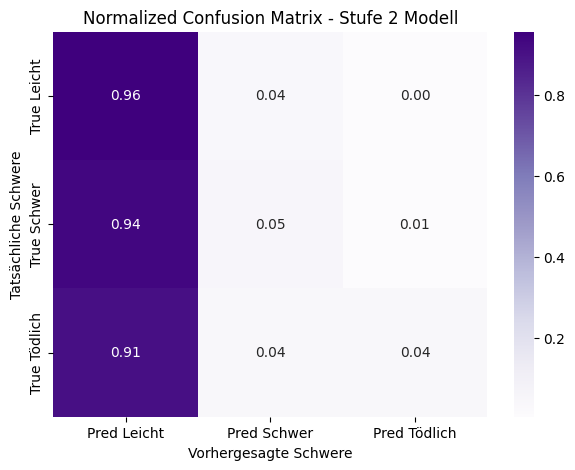

In [5]:
# Filter die Fälle mit Personenschaden (> 0) aus den Originaldaten
train_mask = (y_train.iloc[:, 0] > 0) if isinstance(y_train, pd.DataFrame) else (y_train > 0)
test_mask = (y_test.iloc[:, 0] > 0) if isinstance(y_test, pd.DataFrame) else (y_test > 0)

X_train_stage2 = X_train[train_mask]
X_test_stage2 = X_test[test_mask]

# Original-Zielvariablen holen
y_train_orig = y_train.iloc[:, 0] if isinstance(y_train, pd.DataFrame) else y_train
y_test_orig = y_test.iloc[:, 0] if isinstance(y_test, pd.DataFrame) else y_test

# Klassen ummappen von [1, 2, 3] auf [0, 1, 2] für XGBoost
y_train_stage2 = y_train_orig[train_mask] - 1
y_test_stage2 = y_test_orig[test_mask] - 1

print(f"Datenbasis für Modell 2 (nur Personenschäden):")
print(f"Trainingsdaten: {X_train_stage2.shape[0]} Fälle")
print(f"Testdaten: {X_test_stage2.shape[0]} Fälle\n")

# Neue Klassengewichte für das 3-Klassen-Problem berechnen
from sklearn.utils.class_weight import compute_class_weight
classes_s2 = np.unique(y_train_stage2)
weights_s2 = compute_class_weight(class_weight='balanced', classes=classes_s2, y=y_train_stage2)
class_weights_dict_s2 = dict(zip(classes_s2, weights_s2))

print("Neue Gewichte für Stufe 2 (0=Leicht, 1=Schwer, 2=Tödlich):")
print(class_weights_dict_s2)

sample_weights_s2 = np.array([class_weights_dict_s2[cls] for cls in y_train_stage2])

# Multiklassifikations-XGBoost für Stufe 2 definieren
stage2_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    tree_method='hist',
    enable_categorical=True
)

# Modell trainieren
print("\nStarte Training für Modell-Stufe 2...")
stage2_model.fit(X_train_stage2, y_train_stage2, sample_weight=sample_weights_s2)
print("Training Stufe 2 abgeschlossen.")

# Vorhersagen & Evaluation
y_pred_stage2 = stage2_model.predict(X_test_stage2)

print("\n--- STAGE 2 CLASSIFICATION REPORT (NUR PERSONENSCHÄDEN) ---")
print(classification_report(y_test_stage2, y_pred_stage2, target_names=['Leicht (0)', 'Schwer (1)', 'Tödlich (2)']))

# Konfusionsmatrix plotten
cm_s2 = confusion_matrix(y_test_stage2, y_pred_stage2, normalize='true')
plt.figure(figsize=(7, 5))
sns.heatmap(cm_s2, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=['Pred Leicht', 'Pred Schwer', 'Pred Tödlich'],
            yticklabels=['True Leicht', 'True Schwer', 'True Tödlich'])
plt.ylabel('Tatsächliche Schwere')
plt.xlabel('Vorhergesagte Schwere')
plt.title('Normalized Confusion Matrix - Stufe 2 Modell')
plt.show()

## SHAP installieren und visualisieren
Die Modelle werden nun interpretiert und die Schwachstellen wissenschaftlich erkannt. Dafür wird SHAP auf beide Modelle angewendet.

In [ ]:
!pip install shap
import shap

# ----------Model 1----------
# SHAP Explainer für das binäre Modell initialisieren
explainer = shap.TreeExplainer(model)

# SHAP-Werte für eine Stichprobe von 2000 der Testdaten berechnen
X_test_sample = X_test.sample(2000, random_state=42)
shap_values = explainer(X_test_sample)

# SHAP Summary Plot zeichnen
plt.figure(figsize=(10, 8))
plt.title("SHAP: Richtungseinfluss auf Personenschäden", fontsize=14)
shap.summary_plot(shap_values, X_test_sample)

In [ ]:
# ----------Model 2----------
# 1. SHAP-TreeExplainer für das Multiklassifikation Modell initialisieren
explainer_s2 = shap.TreeExplainer(stage2_model)

# SHAP-Werte berechnen
X_test_s2_sample = X_test_stage2.sample(min(2000, len(X_test_stage2)), random_state=42)
shap_values_s2 = explainer_s2(X_test_s2_sample)

# Erstellung des SHAP-Summary-Plots für die Klassen 0, 1 und 2
# PLOT 1: LEICHTE VERLETZUNGEN (Klasse 0)
plt.figure(figsize=(10, 8))
plt.title("SHAP: Risiko-Faktoren für LEICHTE Unfälle (Stufe 0)", fontsize=14)
shap.summary_plot(shap_values_s2[:, :, 0], X_test_s2_sample)

In [ ]:
# PLOT 2: SCHWERE VERLETZUNGEN (Klasse 1)
plt.figure(figsize=(10, 8))
plt.title("SHAP: Risiko-Faktoren für SCHWERE Unfälle (Stufe 1)", fontsize=14)
shap.summary_plot(shap_values_s2[:, :, 1], X_test_s2_sample)

In [ ]:
# PLOT 3: TÖDLICHE UNFÄLLE (Klasse 2)
plt.figure(figsize=(10, 8))
plt.title("SHAP: Risiko-Faktoren für TÖDLICHE Unfälle (Stufe 2)", fontsize=14)
shap.summary_plot(shap_values_s2[:, :, 2], X_test_s2_sample)